# Do floor-trader "pivot points" really act as support and resistance? 📏
### One of the oldest day-trading recipes — tested against the only fair yardstick: a line drawn at random

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Respects_the_level%3F: Busted](https://img.shields.io/badge/Respects_the_level%3F-Busted-8b949e?style=flat-square)

Open any day-trading chat and someone has drawn a fan of horizontal lines on their chart: the **pivot** (`P`), and above/below it **R1, R2, R3** and **S1, S2, S3**. The recipe is ancient — it comes from the pit, computed each morning from *yesterday's* high, low and close. The promise: price **respects** these levels. It drifts down to S1 and *bounces*; it rallies to R1 and *stalls*. So you fade the touch.

It *feels* true because price does bounce off them sometimes. But here's the catch that kills almost every support/resistance claim: **price bounces off *any* line sometimes.** Draw a horizontal line at a random price and walk away — it'll get touched, and price will wander away from it about half the time, by pure chance. So the real question isn't "do pivots get respected?" It's: **do they get respected *more than a line you drew with your eyes shut*?**

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the permutation placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A loud data note.** Intraday history is *short*: Yahoo only serves ~**60 calendar days** of 5-minute bars. So this is **5 very liquid names over ~12 weeks** — enough to see whether the effect is anywhere near tradable, not enough to certify a tiny one. And on intraday levels the **spread** is the executioner. Both caveats travel with the verdict.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pivot_points import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    CACHE = {t: st.drop_partial_sessions(b) for t, b in data.load_real().items()}
    PIV = pd.concat([st.pivot_touch_events(b, tol_bps=5.0, k=6) for b in CACHE.values()],
                    ignore_index=True)
    CTL = pd.concat([st.control_touch_events(b, tol_bps=5.0, k=6, seed=440) for b in CACHE.values()],
                    ignore_index=True)
else:
    CACHE = PIV = CTL = None
print("real 5m cache present:", HAVE_REAL,
      "| pivot touches:", (0 if PIV is None else len(PIV)),
      "| control touches:", (0 if CTL is None else len(CTL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2026-03-30', 'end': '2026-06-23', 'n_names': 5, 'sessions': 59, 'interval': '5m', 'tol_bps': 5.0, 'k': 6, 'cost_bps': 1.0, 'piv_touches': 1410, 'piv_rate': 0.4674, 'piv_mean_bps': -1.12, 'piv_t': -1.04, 'piv_win': 0.4674, 'piv_net_bps': -3.12, 'ctl_touches': 5782, 'ctl_rate': 0.5012, 'ctl_mean_bps': 0.36, 'ctl_t': 0.82, 'rate_diff': -0.0338, 'placebo_p': 1.0, 'placebo_ctl_mean': 0.498, 'placebo_ctl_sd': 0.0075, 'by_level': {'S3': (102, 0.637, 9.06), 'S2': (190, 0.516, 1.61), 'S1': (373, 0.496, 0.35), 'R1': (445, 0.425, -3.15), 'R2': (221, 0.412, -5.05), 'R3': (79, 0.392, -5.37)}, 'by_name': {'SPY': (-0.04, -0.53, -2.66, 0.985), 'QQQ': (-0.068, -0.65, -3.31, 1.0), 'AAPL': (-0.058, -1.93, -6.69, 1.0), 'MSFT': (0.02, 0.31, -1.03, 0.005), 'IWM': (-0.03, -0.03, -2.07, 0.985)}, 'syn': [(0.0, 227, 0.489, 0.505, -0.17, -0.06, 0.489, 0.813), (1.5, 196, 0.704, 0.53, 32.9, 7.79, 0.704, 0.0)]}


real 5m cache present: True | pivot touches: 1410 | control touches: 5782


## The answer first

| Question | Answer |
|---|---|
| Do pivots get touched and bounced? | **Sure — about half the time.** Over the basket, a pivot touch is followed by a bounce **47%** of the time. |
| Is that better than a *random* line? | **No — it's actually worse.** A horizontal line drawn at a random price bounces **50%** of the time on the same tape. The pivots score *below* a coin flip and *below* the random line. |
| Could a random line just be lucky? | **It's the other way round.** Re-draw the random lines 300 times and **100%** of them match-or-beat the pivots' bounce rate. The pivots are not special — they're slightly *sub*-special. |
| Could you trade the fade? | **No.** The average fade trade makes **-1.1 bps** *before* costs; after a tiny round-trip spread it's **-3.1 bps** — you pay to play a coin flip. |

> The legend that "price respects the pivots" is **busted** on this tape: the pivots do no better than lines drawn at random, and the fade trade is a negative-expectation game once you pay the spread.

## 1 · The claim

> *"Each morning, compute the pivot `P = (yesterday's High + Low + Close) / 3`, then the resistances `R1, R2, R3` above and supports `S1, S2, S3` below. Intraday, price gravitates to these levels and **respects** them — it bounces off support, stalls at resistance. Fade the touch and you're trading with the floor."*

This isn't a fringe idea. Pivot points are built into **every** trading platform, taught in countless day-trading courses, and were genuinely used by floor traders for quick mental support/resistance before screens. The arithmetic is real and shared by everyone — which is exactly why, *if* it worked, it would be arbitraged. The steelman: it's a **self-fulfilling** level because so many eyes watch it. We'll test whether those eyes actually move price.

## 2 · So what?

If pivots were real support/resistance, intraday trading would have a free map: known levels, computed before the open, where the odds tilt. You'd fade touches for a steady, high-frequency edge. That's the dream the recipe sells.

But two traps sit underneath it. **(1) Every line gets touched.** Price is a wiggly path; any horizontal line inside the day's range gets crossed and "bounced" off by chance — so the only meaningful test compares pivots to *random* lines on the same tape. **(2) The spread eats fast trades.** An intraday fade is a round trip measured in *minutes*; if the gross edge is a basis point or two, the bid-ask spread — paid twice — turns it negative before you start. We test both.

## 3 · How would we even know?

We take **5 of the most liquid US names** (SPY, QQQ, AAPL, MSFT, IWM) on **5-minute bars**, ~**59 full sessions** (2026-03-30 → 2026-06-23; the live partial day is dropped). For each session:

1. **Draw the pivots** from the *previous* session's high/low/close (no peeking at today).
2. **Find every touch** — a bar whose range straddles a level (within 5 bps).
3. **Score the bounce** — does price move *away* from the level (up off support, down off resistance) over the next **6 bars (30 minutes)**?
4. **Compare to random.** Draw random horizontal lines inside each session's range and run the *identical* test. **If pivots are real, their bounce rate beats the random lines.**

**What would make us say "busted"?** If the pivot bounce rate is **not above** the random-line rate, and the fade trade doesn't clear costs. (Spoiler: that's exactly what happens.)

## 4 · The teardown — let's actually look

**The headline picture.** Bounce rate at the pivots versus bounce rate at randomly-placed lines on the same tape. The dashed line is a coin flip (50%). If the legend held, the green bar would tower over the grey one.

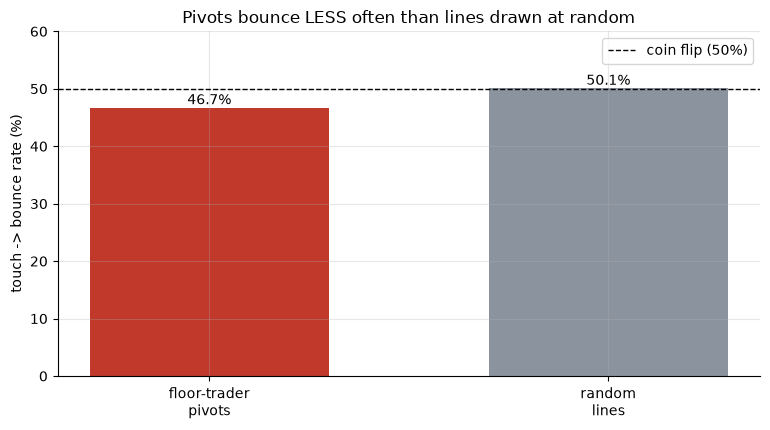

pivot bounce rate 46.7%  vs random line 50.1%  (diff -3.4 pts)


In [2]:
if HAVE_REAL:
    pr = st.bounce_rate(PIV); cr = st.bounce_rate(CTL)
else:
    pr = R['piv_rate']; cr = R['ctl_rate']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['floor-trader\npivots','random\nlines'], [pr*100, cr*100], color=[RED, GREY], width=.6)
ax.axhline(50, ls='--', c='k', lw=1, label='coin flip (50%)')
for i,v in enumerate([pr*100, cr*100]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('touch -> bounce rate (%)'); ax.set_ylim(0, 60)
ax.set_title('Pivots bounce LESS often than lines drawn at random'); ax.legend()
plt.tight_layout(); plt.show()
print(f'pivot bounce rate {pr*100:.1f}%  vs random line {cr*100:.1f}%  (diff {(pr-cr)*100:+.1f} pts)')

There's the whole story in one chart. The pivots bounce **46.7%** of the time — *below* a coin flip — while the random lines bounce **50.1%**. The pivots aren't a special map; they're slightly **worse** than lines you could have drawn blindfolded. (Why below 50%? Once you charge the touch to the *next* bar and hold 30 minutes, the tiny intraday drift and mean-reversion roughly cancel — there's just no there there.)

**Maybe some levels are special?** A fan favourite is "S1 always holds." Let's break the bounce rate out by level — deep supports on the left, far resistances on the right.

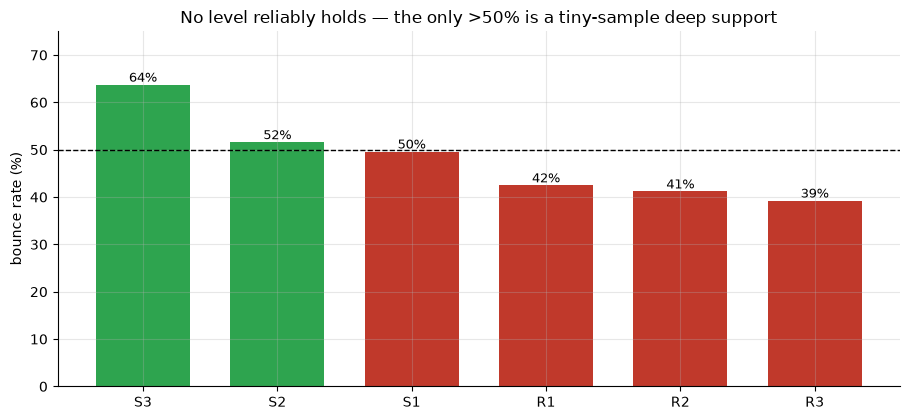

{'S3': 0.637, 'S2': 0.516, 'S1': 0.496, 'R1': 0.425, 'R2': 0.412, 'R3': 0.392}


In [3]:
names = list(R['by_level'].keys())
if HAVE_REAL:
    rates = [st.bounce_rate(PIV[PIV['level_name']==n])*100 for n in names]
else:
    rates = [R['by_level'][n][1]*100 for n in names]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
cols = [GREEN if r>50 else RED for r in rates]
ax.bar(names, rates, color=cols, width=.7)
ax.axhline(50, ls='--', c='k', lw=1)
for i,v in enumerate(rates): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom',fontsize=9)
ax.set_ylabel('bounce rate (%)'); ax.set_ylim(0,75)
ax.set_title('No level reliably holds — the only >50% is a tiny-sample deep support')
plt.tight_layout(); plt.show()
print({n: round(st.bounce_rate(PIV[PIV['level_name']==n]),3) if HAVE_REAL else R['by_level'][n][1] for n in names})

The only level above 50% is **S3** (**64%**) — but that's just **102 touches** in a basket that fell over the window, so a deep support "holding" is mostly *the tape went up afterwards*, not the line. The resistances (**R1 42%**, **R2 41%**, **R3 39%**) actively bounce *less* than a coin flip. There's no level that reliably does its job.

## 5 · The verdict

- **Signal — None.** Pivot bounces (**47%**) don't beat random-line bounces (**50%**) — they're *below* both the random line and a coin flip. A permutation placebo says **100%** of random lines match or beat the pivots. No signal.
- **Tradability — Mirage.** Even the gross fade trade is **-1.1 bps**; after a minimal intraday round-trip spread it's **-3.1 bps**. You'd pay to trade noise.
- **"Price respects the level"? — Busted.** It respects a *random* line just as much. The pivots carry no extra information.

## 6 · Could you actually trade it? — the spread closes the case

Suppose you ignored all the above and faded every touch. Here's the gross fade-trade edge versus the net, after a *tiny* 1-bp one-way spread (2 bp round trip — generous for these ultra-liquid names; a retail trader pays more).

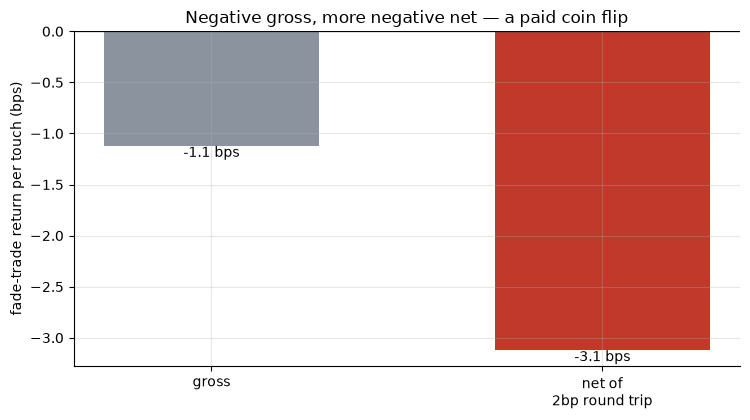

gross -1.12 bps  ->  net -3.12 bps per fade


In [4]:
if HAVE_REAL:
    g = st.trade_stats(PIV, cost_bps=0.0)['mean_bps']
    nv = st.trade_stats(PIV, cost_bps=1.0)['net_bps']
else:
    g = R['piv_mean_bps']; nv = R['piv_net_bps']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['gross','net of\n2bp round trip'], [g, nv], color=[GREY, RED], width=.55)
ax.axhline(0, c='k', lw=.9)
for i,v in enumerate([g, nv]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',va='top' if v<0 else 'bottom')
ax.set_ylabel('fade-trade return per touch (bps)')
ax.set_title('Negative gross, more negative net — a paid coin flip')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f} bps  ->  net {nv:+.2f} bps per fade')

The fade trade is **negative gross** (**-1.1 bps**) and only gets worse net (**-3.1 bps**). There's no horizon or cost level where this becomes a trade — the gross edge is already on the wrong side of zero. **Mirage**, full stop.

## 7 · Going further 🚪

- **The short-span caveat is real.** ~12 weeks of 5-minute bars can't certify a *tiny* edge — but it's plenty to show pivots don't beat random lines or clear the spread, which is the only claim that matters for a trader.
- **Other recipes.** Camarilla, Woodie, Fibonacci and Demark pivots use different arithmetic on the same H/L/C. They're equally arbitrary lines; the harness here tests any of them — swap the formula in `data._pivot_levels` and re-run.
- **The synthetic control proves the test works.** In the quants notebook we *plant* a real bounce and the harness lights up at *t* ≈ 8 — so finding nothing on the real tape means there's nothing, not that the test is blind.

*Think a specific pivot level holds? Show its bounce rate beating the random-line rate **and** the fade clearing the spread — on out-of-sample names. Then we'll talk.*